# Thickets (Gemma): RandOpt vs ES on mock Wordle

**Pretrained thicket setup:** frozen **`google/gemma-3-1b-it`** + **trainable linear head** over the mock action vocabulary (same idea as `week12_implementation.ipynb`).

This notebook mirrors **`thickets_comp_week_12.ipynb`** (greedy random search vs evolution strategies at matched inner episode-eval budget) but optimizes **only trainable weights** (head ± LoRA), consistent with `es_wordle.train_es_wordle`.

**Requires:** `transformers`, `torch`, `jinja2>=3.1` (chat template), Hugging Face access for Gemma. For a fast CPU-only sanity check, reduce `n_iterations` / `N` in the config cell.


In [1]:
import copy
import os
import random
import sys
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn

_here = Path.cwd().resolve()
ROOT = _here.parent if _here.name == "notebooks" else _here
SRC = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

os.environ.setdefault("HF_HUB_DISABLE_XET", "1")

from es_wordle import train_es_wordle
from wordle_env import load_wordle_environment
from wordle_gpt2_policy import WordleGPT2Policy, TRANSFORMERS_AVAILABLE

if not TRANSFORMERS_AVAILABLE:
    raise ImportError("pip install transformers")


In [2]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


def choose_device() -> torch.device:
    if torch.cuda.is_available():
        return torch.device("cuda")
    mps = getattr(torch.backends, "mps", None)
    if mps is not None and mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")


def default_model_load_kwargs(device: torch.device) -> dict:
    if device.type != "cuda":
        return {}
    if torch.cuda.is_bf16_supported():
        return {"torch_dtype": torch.bfloat16}
    return {"torch_dtype": torch.float16}


device = choose_device()
print("device:", device)

MODEL_NAME = "google/gemma-3-1b-it"
USE_PRIME_TARGETS = False
RICHER_PROMPT = True
USE_CHAT_TEMPLATE = True
CHAT_GENERATION_PROMPT = True
MAX_PROMPT_LENGTH = 512
MAX_VOCAB = 8  # mock Wordle: eight actions
USE_LORA = False
LORA_R = 4

MODEL_LOAD_KWARGS = default_model_load_kwargs(device)
print("model:", MODEL_NAME, "| LoRA:", USE_LORA, "| load kwargs:", MODEL_LOAD_KWARGS or {"dtype": "float32"})


device: cuda
model: google/gemma-3-1b-it | LoRA: False | load kwargs: {'torch_dtype': torch.bfloat16}


In [3]:
env = load_wordle_environment(
    num_train_examples=1000,
    num_eval_examples=200,
    use_prime_intellect=False,
)

print(f"Environment loaded. max_turns={env.max_turns}, episodes={env.num_episodes}")


[OK] Mock Wordle environment (Prime Intellect disabled; targets from MOCK_WORDLE_TARGETS).
Environment loaded. max_turns=6, episodes=1000


In [4]:
def make_policy():
    policy = WordleGPT2Policy(
        model_name=MODEL_NAME,
        use_prime_targets=USE_PRIME_TARGETS,
        max_vocab_size=MAX_VOCAB,
        max_prompt_length=MAX_PROMPT_LENGTH,
        include_mock_targets_in_vocab=True,
        richer_prompt=RICHER_PROMPT,
        use_chat_template=USE_CHAT_TEMPLATE,
        chat_generation_prompt=CHAT_GENERATION_PROMPT,
        use_lora=USE_LORA,
        lora_r=LORA_R,
        model_kwargs=MODEL_LOAD_KWARGS,
    ).to(device)
    return policy


In [5]:
def clone_policy(policy: nn.Module) -> nn.Module:
    return copy.deepcopy(policy)


def _trainable_params(policy: nn.Module):
    # Same rule as es_wordle: only optimize parameters with requires_grad.
    return [p for p in policy.parameters() if p.requires_grad]


def get_param_vector(policy: nn.Module) -> torch.Tensor:
    if not list(_trainable_params(policy)):
        raise RuntimeError("No trainable parameters.")
    return torch.cat([p.data.view(-1).detach().cpu() for p in _trainable_params(policy)])


def set_param_vector(policy: nn.Module, vec: torch.Tensor) -> None:
    vec = vec.to(device)
    offset = 0
    for p in _trainable_params(policy):
        n = p.numel()
        p.data.copy_(vec[offset : offset + n].view_as(p))
        offset += n


def count_params(policy: nn.Module) -> int:
    return sum(p.numel() for p in _trainable_params(policy))


In [6]:
import re


def extract_guess_from_xml(action_xml: str) -> str:
    match = re.search(r"<guess>(.*?)</guess>", action_xml)
    return match.group(1).strip() if match else "?????"


def play_one_game(policy, env, deterministic=True, verbose=False):
    state = env.reset()
    done = False
    turns = 0
    total_reward = 0.0
    guesses = []

    policy.eval()
    with torch.no_grad():
        while not done and turns < env.max_turns:
            state_embedding = env.get_state_embedding(state)
            action_xml, _ = policy.format_action_xml(
                state,
                state_embedding,
                deterministic=deterministic,
            )

            guess = extract_guess_from_xml(action_xml)
            guesses.append(guess)

            state, reward, done, info = env.step(action_xml)
            total_reward += float(reward)
            turns += 1

            if verbose:
                print(f"Turn {turns}: {guess} | reward={reward:.3f}")
                if "feedback" in info:
                    print("  feedback:", info["feedback"])

    success = float(info.get("correct_answer", 0.0)) > 0.5
    return {
        "success": success,
        "turns": turns,
        "reward": total_reward,
        "guesses": guesses,
        "target": getattr(state, "target_word", None),
    }


def evaluate_policy_fixed(policy, env, n_episodes=50, deterministic=True):
    results = [
        play_one_game(policy, env, deterministic=deterministic, verbose=False)
        for _ in range(n_episodes)
    ]

    success_rate = np.mean([r["success"] for r in results])
    avg_reward = np.mean([r["reward"] for r in results])
    avg_turns = np.mean([r["turns"] for r in results])

    solved_turns = [r["turns"] for r in results if r["success"]]
    avg_turns_success_only = np.mean(solved_turns) if solved_turns else float("nan")

    return {
        "success_rate": float(success_rate),
        "avg_reward": float(avg_reward),
        "avg_turns": float(avg_turns),
        "avg_turns_success_only": float(avg_turns_success_only)
        if solved_turns
        else float("nan"),
        "n_episodes": n_episodes,
        "raw": results,
    }


In [7]:
def train_randopt_wordle(
    base_policy,
    env,
    N=300,
    sigma=0.01,
    n_eval_episodes=10,
    score_key="avg_reward",
    verbose=True,
):
    best_policy = clone_policy(base_policy)
    best_vec = get_param_vector(best_policy)

    best_metrics = evaluate_policy_fixed(best_policy, env, n_episodes=n_eval_episodes)
    best_score = best_metrics[score_key]

    history = [
        {
            "step": 0,
            "best_score": best_score,
            "success_rate": best_metrics["success_rate"],
            "avg_reward": best_metrics["avg_reward"],
            "avg_turns": best_metrics["avg_turns"],
        }
    ]

    if verbose:
        print(
            f"[RandOpt] step 0/{N} | "
            f"score={best_score:.4f} | "
            f"success={best_metrics['success_rate']:.3f} | "
            f"reward={best_metrics['avg_reward']:.3f}"
        )

    for i in range(1, N + 1):
        candidate = clone_policy(base_policy)
        noise = torch.randn_like(best_vec) * sigma
        cand_vec = best_vec + noise
        set_param_vector(candidate, cand_vec)

        metrics = evaluate_policy_fixed(candidate, env, n_episodes=n_eval_episodes)
        score = metrics[score_key]

        if score > best_score:
            best_score = score
            best_vec = cand_vec.clone()
            best_policy = candidate
            best_metrics = metrics

        history.append(
            {
                "step": i,
                "best_score": best_score,
                "success_rate": best_metrics["success_rate"],
                "avg_reward": best_metrics["avg_reward"],
                "avg_turns": best_metrics["avg_turns"],
            }
        )

        if verbose and (i % max(1, N // 10) == 0 or i == N):
            print(
                f"[RandOpt] step {i}/{N} | "
                f"best_score={best_score:.4f} | "
                f"success={best_metrics['success_rate']:.3f} | "
                f"reward={best_metrics['avg_reward']:.3f}"
            )

    return best_policy, history


In [8]:
base_policy = make_policy()
print("trainable (ES/RandOpt):", base_policy.count_trainable_parameters())
print("total params:", base_policy.count_parameters())

init_eval = evaluate_policy_fixed(base_policy, env, n_episodes=50)
print("Initial baseline:")
print(init_eval)


`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/340 [00:00<?, ?it/s]

trainable (ES/RandOpt): 9224
total params: 999895176
Initial baseline:
{'success_rate': 0.7, 'avg_reward': 1.4025999999999998, 'avg_turns': 3.82, 'avg_turns_success_only': 2.8857142857142857, 'n_episodes': 50, 'raw': [{'success': False, 'turns': 6, 'reward': 0.5399999999999999, 'guesses': ['AUDIO', 'LIGHT', 'CRANE', 'HEART', 'DREAM', 'PLANT'], 'target': 'SLATE'}, {'success': True, 'turns': 3, 'reward': 1.6633333333333333, 'guesses': ['AUDIO', 'LIGHT', 'CRANE'], 'target': 'CRANE'}, {'success': True, 'turns': 5, 'reward': 1.8266666666666667, 'guesses': ['AUDIO', 'LIGHT', 'CRANE', 'HEART', 'PLANT'], 'target': 'PLANT'}, {'success': True, 'turns': 1, 'reward': 1.8, 'guesses': ['AUDIO'], 'target': 'AUDIO'}, {'success': True, 'turns': 1, 'reward': 1.8, 'guesses': ['AUDIO'], 'target': 'AUDIO'}, {'success': False, 'turns': 6, 'reward': 0.63, 'guesses': ['AUDIO', 'LIGHT', 'CRANE', 'HEART', 'PLANT', 'DREAM'], 'target': 'TRACE'}, {'success': False, 'turns': 6, 'reward': 0.5399999999999999, 'guesse

In [9]:
policy_randopt = clone_policy(base_policy)
policy_es = clone_policy(base_policy)


In [10]:
# Match RandOpt steps to ES inner episode-eval budget:
# ES uses n_iterations * N * n_eval_episodes perturbation-eval episodes per run.
# RandOpt uses one candidate eval of n_eval_episodes per step.

es_config = {
    "N": 8,
    "sigma": 0.02,
    "alpha": 0.1,
    "n_iterations": 8,
    "n_eval_episodes": 4,
    "max_turns": 6,
    "eval_every": 2,
    "verbose": True,
    "eval_n_episodes": 8,
    "eval_deterministic": True,
    "fitness_objective": "win_plus_return",
    "win_fitness_scale": 5.0,
    "normalize_gradient": True,
    "rank_fitness": True,
}

inner_episodes = es_config["n_iterations"] * es_config["N"] * es_config["n_eval_episodes"]
randopt_n_eval = es_config["n_eval_episodes"]
randopt_steps = inner_episodes // max(1, randopt_n_eval)

randopt_config = {
    "N": randopt_steps,
    "sigma": es_config["sigma"],
    "n_eval_episodes": randopt_n_eval,
    "score_key": "avg_reward",
    "verbose": True,
}

print("ES inner episode eval budget:", inner_episodes)
print("RandOpt steps × eval eps:", randopt_config["N"] * randopt_config["n_eval_episodes"])


ES inner episode eval budget: 256
RandOpt steps × eval eps: 256


In [11]:
best_randopt_policy, randopt_history = train_randopt_wordle(
    base_policy=policy_randopt,
    env=env,
    **randopt_config
)


[RandOpt] step 0/64 | score=1.7750 | success=1.000 | reward=1.775
[RandOpt] step 6/64 | best_score=1.8050 | success=1.000 | reward=1.805
[RandOpt] step 12/64 | best_score=1.9042 | success=1.000 | reward=1.904
[RandOpt] step 18/64 | best_score=1.9042 | success=1.000 | reward=1.904
[RandOpt] step 24/64 | best_score=1.9042 | success=1.000 | reward=1.904
[RandOpt] step 30/64 | best_score=1.9042 | success=1.000 | reward=1.904
[RandOpt] step 36/64 | best_score=1.9042 | success=1.000 | reward=1.904
[RandOpt] step 42/64 | best_score=1.9708 | success=1.000 | reward=1.971
[RandOpt] step 48/64 | best_score=1.9708 | success=1.000 | reward=1.971
[RandOpt] step 54/64 | best_score=1.9708 | success=1.000 | reward=1.971
[RandOpt] step 60/64 | best_score=1.9708 | success=1.000 | reward=1.971
[RandOpt] step 64/64 | best_score=1.9708 | success=1.000 | reward=1.971


In [12]:
import importlib
import es_wordle
import wordle_env

importlib.reload(es_wordle)
importlib.reload(wordle_env)
history_es = es_wordle.train_es_wordle(
    policy=policy_es,
    env=env,
    **es_config
)

best_iter = history_es["best_iter"][0]
best_eval_success = history_es["best_eval_success"][0]

best_eval_reward = float("nan")
if best_iter in history_es["iteration"]:
    best_eval_idx = history_es["iteration"].index(best_iter)
    best_eval_reward = history_es["eval_reward"][best_eval_idx]

print("ES best iteration:", best_iter)
print("ES best eval success:", best_eval_success)
print("ES best eval reward:", best_eval_reward)

final_es = evaluate_policy_fixed(policy_es, env, n_episodes=100)
print("Final ES test:", final_es)


Iter    0 | Fit(win+ret):  5.599 | ES_win: 81.2% | popσ: 0.6753 | Eval Reward:  1.303 | Success: 62.5% (greedy) | Turns:  5.4 | Grad‖: 1588.91 | Step‖: 0.1000 | cos(ĝ):   n/a | ‖θ-θ₀‖: 0.10 | ess: 8/8 | wins: 8/8 | dprobe: -6.2%
Iter    1 | Fit(win+ret):  4.808 | ES_win: 68.8% | popσ: 1.0431 | Grad‖: 1600.05 | Step‖: 0.1000 | cos(ĝ): +0.01 | ‖θ-θ₀‖: 0.14 | ess: 8/8 | wins: 8/8 | (no eval)
Iter    2 | Fit(win+ret):  5.188 | ES_win: 75.0% | popσ: 1.0844 | Eval Reward:  0.905 | Success: 37.5% (greedy) | Turns:  4.9 | Grad‖: 1584.92 | Step‖: 0.1000 | cos(ĝ): +0.01 | ‖θ-θ₀‖: 0.17 | ess: 8/8 | wins: 8/8 | dprobe: +0.0%
Iter    3 | Fit(win+ret):  5.387 | ES_win: 78.1% | popσ: 1.4516 | Grad‖: 1589.77 | Step‖: 0.1000 | cos(ĝ): +0.00 | ‖θ-θ₀‖: 0.20 | ess: 8/8 | wins: 8/8 | (no eval)
Iter    4 | Fit(win+ret):  5.180 | ES_win: 75.0% | popσ: 1.4030 | Eval Reward:  1.445 | Success: 75.0% (greedy) | Turns:  4.6 | Grad‖: 1580.93 | Step‖: 0.1000 | cos(ĝ): -0.00 | ‖θ-θ₀‖: 0.22 | ess: 8/8 | wins: 8/8 | d

In [13]:
final_es_greedy = evaluate_policy_fixed(policy_es, env, n_episodes=100)
final_es_stochastic = evaluate_policy_fixed(
    policy_es, env, n_episodes=100, deterministic=False
)

print("ES greedy eval:", final_es_greedy)
print("ES stochastic eval:", final_es_stochastic)


ES greedy eval: {'success_rate': 0.77, 'avg_reward': 1.4815333333333336, 'avg_turns': 4.24, 'avg_turns_success_only': 3.7142857142857144, 'n_episodes': 100, 'raw': [{'success': True, 'turns': 5, 'reward': 1.7966666666666669, 'guesses': ['LIGHT', 'HEART', 'DREAM', 'AUDIO', 'TRACE'], 'target': 'TRACE'}, {'success': True, 'turns': 6, 'reward': 1.7433333333333334, 'guesses': ['LIGHT', 'HEART', 'DREAM', 'AUDIO', 'TRACE', 'PLANT'], 'target': 'PLANT'}, {'success': True, 'turns': 6, 'reward': 1.7433333333333334, 'guesses': ['LIGHT', 'HEART', 'DREAM', 'AUDIO', 'TRACE', 'PLANT'], 'target': 'PLANT'}, {'success': True, 'turns': 3, 'reward': 1.7233333333333334, 'guesses': ['LIGHT', 'HEART', 'DREAM'], 'target': 'DREAM'}, {'success': False, 'turns': 6, 'reward': 0.5700000000000001, 'guesses': ['LIGHT', 'HEART', 'DREAM', 'AUDIO', 'TRACE', 'PLANT'], 'target': 'SLATE'}, {'success': True, 'turns': 3, 'reward': 1.7233333333333334, 'guesses': ['LIGHT', 'HEART', 'DREAM'], 'target': 'DREAM'}, {'success': Tru

In [14]:
final_init = evaluate_policy_fixed(base_policy, env, n_episodes=100)
final_randopt = evaluate_policy_fixed(best_randopt_policy, env, n_episodes=100)
final_es = evaluate_policy_fixed(policy_es, env, n_episodes=100)

print("Initial:", final_init)
print("RandOpt:", final_randopt)
print("ES:", final_es)


Initial: {'success_rate': 0.76, 'avg_reward': 1.4777, 'avg_turns': 4.03, 'avg_turns_success_only': 3.4078947368421053, 'n_episodes': 100, 'raw': [{'success': True, 'turns': 3, 'reward': 1.6633333333333333, 'guesses': ['AUDIO', 'LIGHT', 'CRANE'], 'target': 'CRANE'}, {'success': True, 'turns': 3, 'reward': 1.6633333333333333, 'guesses': ['AUDIO', 'LIGHT', 'CRANE'], 'target': 'CRANE'}, {'success': True, 'turns': 5, 'reward': 1.7366666666666668, 'guesses': ['AUDIO', 'LIGHT', 'CRANE', 'HEART', 'DREAM'], 'target': 'DREAM'}, {'success': True, 'turns': 5, 'reward': 1.8266666666666667, 'guesses': ['AUDIO', 'LIGHT', 'CRANE', 'HEART', 'PLANT'], 'target': 'PLANT'}, {'success': True, 'turns': 1, 'reward': 1.8, 'guesses': ['AUDIO'], 'target': 'AUDIO'}, {'success': True, 'turns': 4, 'reward': 1.79, 'guesses': ['AUDIO', 'LIGHT', 'CRANE', 'HEART'], 'target': 'HEART'}, {'success': True, 'turns': 1, 'reward': 1.8, 'guesses': ['AUDIO'], 'target': 'AUDIO'}, {'success': True, 'turns': 1, 'reward': 1.8, 'gue

In [15]:
def summarize_metrics(name, metrics):
    return {
        "method": name,
        "success_rate": round(metrics["success_rate"], 4),
        "avg_reward": round(metrics["avg_reward"], 4),
        "avg_turns": round(metrics["avg_turns"], 4),
        "avg_turns_success_only": (
            round(metrics["avg_turns_success_only"], 4)
            if not np.isnan(metrics["avg_turns_success_only"])
            else None
        ),
        "n_eval_episodes": metrics["n_episodes"],
    }


summary = [
    summarize_metrics("Initial", final_init),
    summarize_metrics("RandOpt", final_randopt),
    summarize_metrics("ES", final_es),
]

for row in summary:
    print(row)


{'method': 'Initial', 'success_rate': 0.76, 'avg_reward': 1.4777, 'avg_turns': 4.03, 'avg_turns_success_only': 3.4079, 'n_eval_episodes': 100}
{'method': 'RandOpt', 'success_rate': 0.87, 'avg_reward': 1.6596, 'avg_turns': 4.53, 'avg_turns_success_only': 4.3103, 'n_eval_episodes': 100}
{'method': 'ES', 'success_rate': 0.72, 'avg_reward': 1.4318, 'avg_turns': 4.1, 'avg_turns_success_only': 3.3611, 'n_eval_episodes': 100}


In [16]:
def compare_two(a_name, a, b_name, b):
    print(f"{a_name} success rate: {a['success_rate']:.3f}")
    print(f"{b_name} success rate: {b['success_rate']:.3f}")
    print(f"Δ success ({b_name} - {a_name}): {b['success_rate'] - a['success_rate']:+.3f}")
    print()
    print(f"{a_name} avg reward: {a['avg_reward']:.3f}")
    print(f"{b_name} avg reward: {b['avg_reward']:.3f}")
    print(f"Δ reward ({b_name} - {a_name}): {b['avg_reward'] - a['avg_reward']:+.3f}")


print("RandOpt vs ES (Gemma head)")
compare_two("RandOpt", final_randopt, "ES", final_es)


RandOpt vs ES (Gemma head)
RandOpt success rate: 0.870
ES success rate: 0.720
Δ success (ES - RandOpt): -0.150

RandOpt avg reward: 1.660
ES avg reward: 1.432
Δ reward (ES - RandOpt): -0.228


In [17]:
rand_steps = [h["step"] for h in randopt_history]
rand_best_score = [h["best_score"] for h in randopt_history]
rand_success = [h["success_rate"] for h in randopt_history]
rand_reward = [h["avg_reward"] for h in randopt_history]
rand_turns = [h["avg_turns"] for h in randopt_history]


In [18]:
es_train_iter = history_es["train_iter"]
es_train_fitness = history_es["train_fitness"]
es_train_win = history_es["train_es_win"]

es_eval_iter = history_es["iteration"]
es_eval_reward = history_es["eval_reward"]
es_eval_success = history_es["eval_success"]
es_eval_turns = history_es["eval_turns"]


mkdir -p failed for path /home/ubuntu/.config/matplotlib: [Errno 13] Permission denied: '/home/ubuntu/.config/matplotlib'
Matplotlib created a temporary cache directory at /tmp/matplotlib-g36rnw_l because there was an issue with the default path (/home/ubuntu/.config/matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


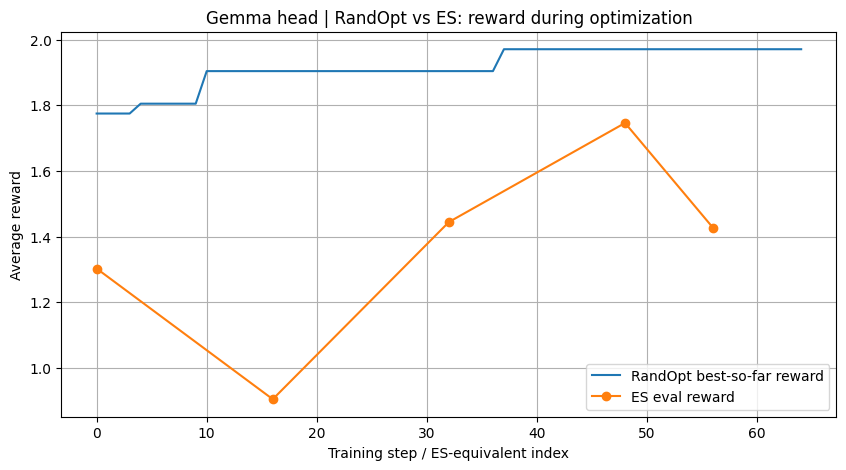

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(rand_steps, rand_reward, label="RandOpt best-so-far reward")
es_x = [i * es_config["N"] for i in es_eval_iter]

plt.plot(es_x, es_eval_reward, marker="o", label="ES eval reward")
plt.xlabel("Training step / ES-equivalent index")
plt.ylabel("Average reward")
plt.title("Gemma head | RandOpt vs ES: reward during optimization")
plt.legend()
plt.grid(True)
plt.show()


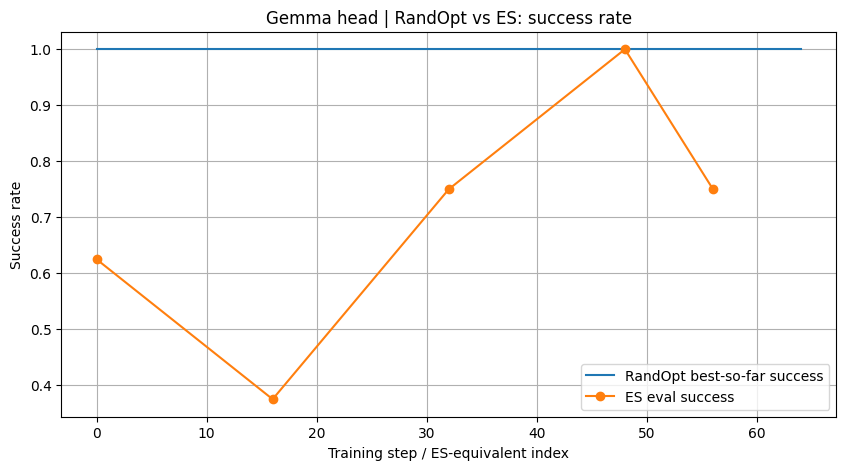

In [20]:
plt.figure(figsize=(10, 5))
plt.plot(rand_steps, rand_success, label="RandOpt best-so-far success")
es_x = [i * es_config["N"] for i in es_eval_iter]

plt.plot(es_x, es_eval_success, marker="o", label="ES eval success")
plt.xlabel("Training step / ES-equivalent index")
plt.ylabel("Success rate")
plt.title("Gemma head | RandOpt vs ES: success rate")
plt.legend()
plt.grid(True)
plt.show()


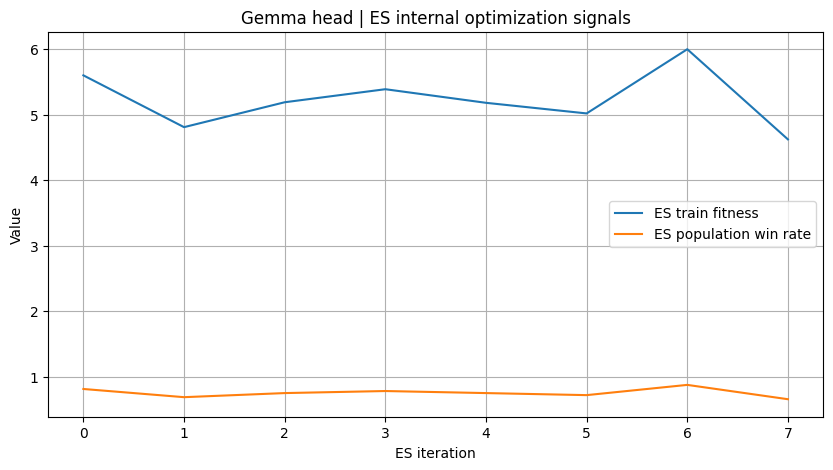

In [21]:
plt.figure(figsize=(10, 5))
plt.plot(es_train_iter, es_train_fitness, label="ES train fitness")
plt.plot(es_train_iter, es_train_win, label="ES population win rate")
plt.xlabel("ES iteration")
plt.ylabel("Value")
plt.title("Gemma head | ES internal optimization signals")
plt.legend()
plt.grid(True)
plt.show()


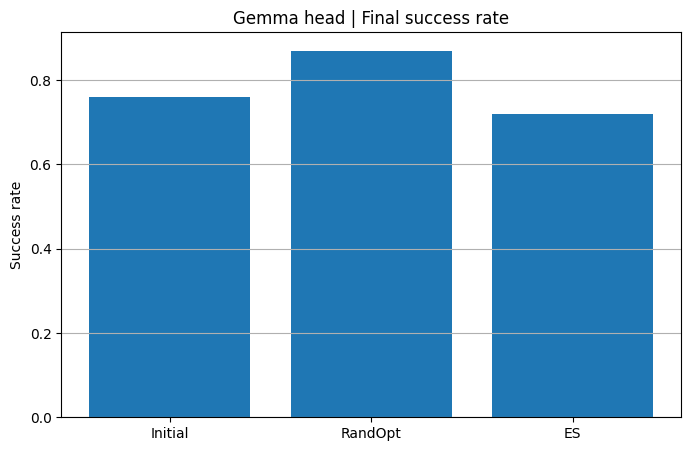

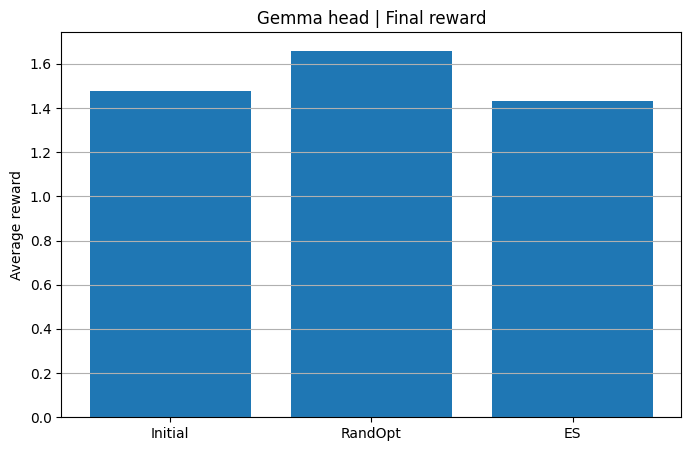

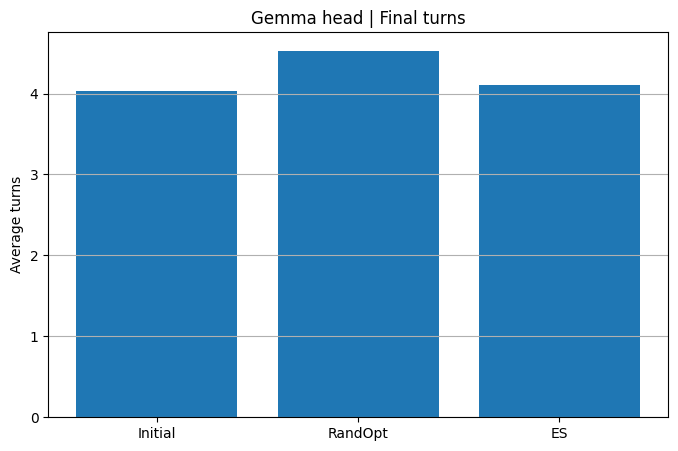

In [22]:
methods = ["Initial", "RandOpt", "ES"]
success_vals = [
    final_init["success_rate"],
    final_randopt["success_rate"],
    final_es["success_rate"],
]
reward_vals = [
    final_init["avg_reward"],
    final_randopt["avg_reward"],
    final_es["avg_reward"],
]
turn_vals = [
    final_init["avg_turns"],
    final_randopt["avg_turns"],
    final_es["avg_turns"],
]

plt.figure(figsize=(8, 5))
plt.bar(methods, success_vals)
plt.ylabel("Success rate")
plt.title("Gemma head | Final success rate")
plt.grid(True, axis="y")
plt.show()

plt.figure(figsize=(8, 5))
plt.bar(methods, reward_vals)
plt.ylabel("Average reward")
plt.title("Gemma head | Final reward")
plt.grid(True, axis="y")
plt.show()

plt.figure(figsize=(8, 5))
plt.bar(methods, turn_vals)
plt.ylabel("Average turns")
plt.title("Gemma head | Final turns")
plt.grid(True, axis="y")
plt.show()
